In [1]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Wheat Futures Historical Data.csv'].decode('utf-8')), index_col='Date', parse_dates=True)

Saving US Wheat Futures Historical Data.csv to US Wheat Futures Historical Data (3).csv


In [4]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.

In [5]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-5-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


<Axes: xlabel='Date'>

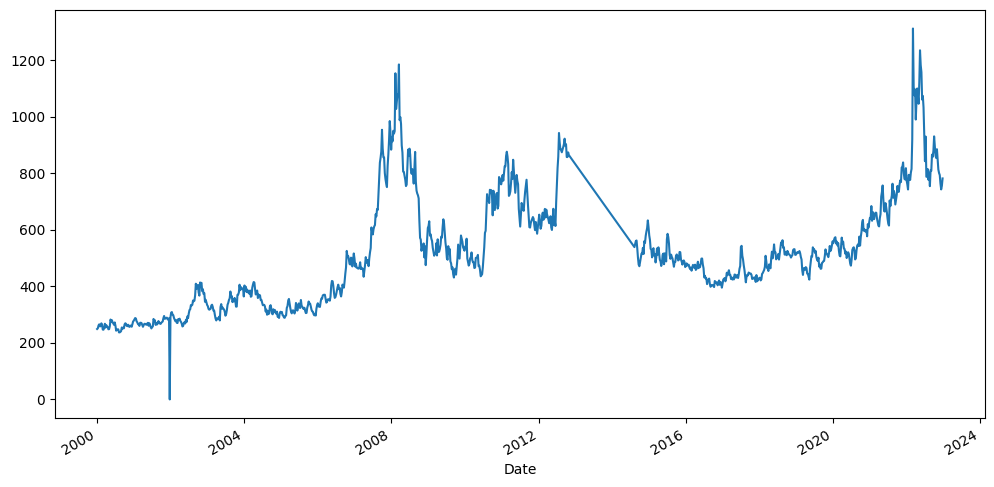

In [6]:
data["Open"].plot(figsize=(12,6))

In [7]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [8]:
ad_test(data['Price'])

1. ADF:  -2.080254015937831
2. p-value:  0.2525283241066988
3. No. of lags:  17
4. No. of observations used for ADF Regression and Critical Values Calculations:  1069
5. Critical Values: 
	 1% , -3.4364819663568262
	 5% , -2.864247479652846
	 10% , -2.568211560046239


In [9]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [10]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=10631.013, Time=2.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=10654.296, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=10641.063, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=10641.208, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=10652.549, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=10642.244, Time=1.57 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=10638.857, Time=1.84 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=10632.897, Time=2.14 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=10632.899, Time=1.34 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=10643.014, Time=0.32 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=10637.362, Time=0.75 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=10633.784, Time=0.94 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=10619.354, Time=1.79 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=10620.403, Time=2.86 sec
 ARIMA(3,1,4)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1087
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5301.778
Date:                Wed, 31 May 2023   AIC                          10617.555
Time:                        05:59:28   BIC                          10652.487
Sample:                             0   HQIC                         10630.779
                               - 1087                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -2.2579      0.119    -18.909      0.000      -2.492      -2.024
ar.L2         -1.7575      0.225     -7.802      0.000      -2.199      -1.316
ar.L3         -0.4766      0.114     -4.167      0.000      -0.701      -0.252
ma.L1          2.1595      0.126     17.111      0.000       1.912       2.407
ma.L2          1.5067      0.242      6.220      0.000       1.032       1.981
ma.L3          0.3165      0.124      2.548      0.011       0.073       0.560
sigma2      1018.1577     17.102     59.534      0.000     984.638    1051.677
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):            111221.52
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                            -1.32
Prob(H) (two-sided):                  0.00   Kurtosis:                        52.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [12]:
num_rows = data.shape[0]
print("Number of rows:", num_rows)

Number of rows: 1087


In [13]:
import statsmodels.api as sm

In [14]:
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-22]
test=data.iloc[-22:]
print(train.shape, test.shape)

(1087, 5)
(1065, 5) (22, 5)


In [15]:
# Taining the model
model=sm.tsa.arima.ARIMA(train['Price'], order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 1065
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -5216.258
Date:                Wed, 31 May 2023   AIC                          10448.516
Time:                        05:59:29   BIC                          10488.282
Sample:                             0   HQIC                         10463.584
                               - 1065                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        515.6391     99.948      5.159      0.000     319.744     711.534
ar.L1          0.9875      0.005    191.497      0.000       0.977       0.998
ma.L1         -0.1025      0.017     -5.867      0.000      -0.137      -0.068
ma.L2          0.0226      0.029      0.777      0.437      -0.034       0.080
ma.L3          0.0635      0.028      2.228      0.026       0.008       0.119
ma.L4         -0.0797      0.025     -3.192      0.001      -0.129      -0.031
ma.L5          0.0567      0.027      2.100      0.036       0.004       0.110
sigma2      1047.8284     17.808     58.840      0.000    1012.925    1082.732
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            109733.61
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                            -0.99
Prob(H) (two-sided):                  0.00   Kurtosis:                        52.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
# Make predictions on the Test dataset
start = len(train)
end = len(train) + len(test)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

1065    272.050170
1066    274.186772
1067    278.873011
1068    281.023648
1069    284.059676
1070    286.958440
1071    289.820920
1072    292.647569
1073    295.438836
1074    298.195163
1075    300.916989
1076    303.604744
1077    306.258856
1078    308.879746
1079    311.467828
1080    314.023515
1081    316.547211
1082    319.039318
1083    321.500229
1084    323.930337
1085    326.330026
1086    328.699677
Name: predicted_mean, dtype: float64
Date
2000-05-28    272.050170
2000-05-21    274.186772
2000-05-14    278.873011
2000-05-07    281.023648
2000-04-30    284.059676
2000-04-23    286.958440
2000-04-16    289.820920
2000-04-09    292.647569
2000-04-02    295.438836
2000-03-26    298.195163
2000-03-19    300.916989
2000-03-12    303.604744
2000-03-05    306.258856
2000-02-27    308.879746
2000-02-20    311.467828
2000-02-13    314.023515
2000-02-06    316.547211
2000-01-30    319.039318
2000-01-23    321.500229
2000-01-16    323.930337
2000-01-09    326.330026
2000-01-02    3

<Axes: xlabel='Date'>

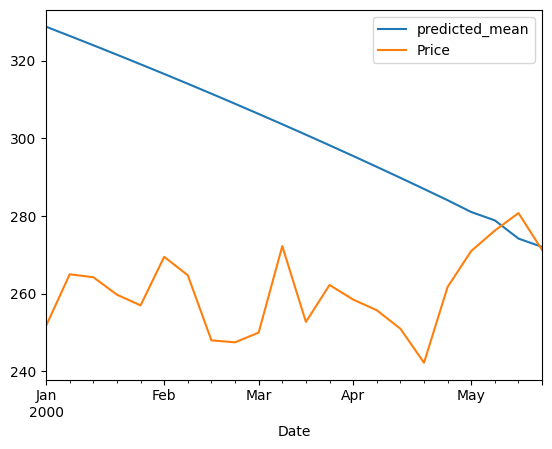

In [17]:
# Plotting the predicted values and the test set
pred.plot(legend=True)
test['Price'].plot(legend=True)

In [18]:
test['Price'].mean()

260.60227272727275

In [19]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test['Price'], pred))
print(rmse)

46.702245269060604
